# Predicting Customer Spending Behaviour in Streaming Services

In [ ]:
#importing relevant libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [ ]:
# Loading the CSV file into a DataFrame with error handling
try:
    streaming_df = pd.read_csv("Streaming.csv")
    print("The file 'Streaming.csv' was uploaded successfully" )
except FileNotFoundError:
    print("Error: The file 'Streaming.csv' was not found.")
except Exception as e:
    print("An unexpected error occurred:", e)

The file 'Streaming.csv' was uploaded successfully


In [ ]:
#viewing dataframe
streaming_df

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST004996,24.0,Male,5,East,Debit Card,0,8.0,18.03,121,51.61,0
4996,CUST004997,66.0,Female,12,East,PayPal,3,5.0,5.84,192,36.32,0
4997,CUST004998,26.0,Female,1,East,Credit Card,2,8.0,6.76,354,42.07,1
4998,CUST004999,53.0,Female,44,South,Debit Card,1,10.0,5.95,31,60.09,0


In [ ]:
#Getting an overviw of the data set
streaming_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      4500 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


# Data Cleaning

In [ ]:
#Determing if there are any empty values (NaN)
streaming_df.isna().any().any()

np.True_

In [ ]:
#checking for features with NaN values
streaming_df.isna().sum()

Customer_ID                 0
Age                       500
Gender                      0
Subscription_Length         0
Region                      0
Payment_Method              0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

In [ ]:
#Determining the median of age to be populated in the NaN values
age_median = streaming_df['Age'].median()
print("Median Age:", age_median)

#Imputing median of Age in place of NaN
streaming_df['Age'] = streaming_df['Age'].fillna(age_median)

Median Age: 43.0


In [ ]:
# Defining the mode of satisfaction score to be populated in the NaN values
satisfaction_mode = streaming_df['Satisfaction_Score'].mode()[0]
print("Satisfaction Score:", satisfaction_mode)

# Filling the mode of satisfaction score in place of NaN
streaming_df['Satisfaction_Score'] = streaming_df['Satisfaction_Score'].fillna(satisfaction_mode)

Satisfaction Score: 6.0


In [ ]:
#cross-checking for null and empty values again
streaming_df.isna().sum()

Customer_ID               0
Age                       0
Gender                    0
Subscription_Length       0
Region                    0
Payment_Method            0
Support_Tickets_Raised    0
Satisfaction_Score        0
Discount_Offered          0
Last_Activity             0
Monthly_Spend             0
Churned                   0
dtype: int64

# Exploratory Data Analysis

<Axes: xlabel='Monthly_Spend', ylabel='Count'>

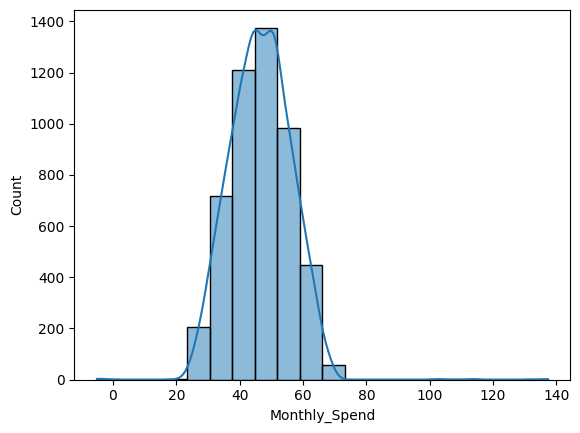

In [ ]:
#Visualizing output feature
sns.histplot(streaming_df["Monthly_Spend"], bins = 20, kde = True)

In [ ]:
# Creating a summary table showing how many customers fall into specific ranges of Monthly Spend.
# Group the 'Monthly_Spend' values into 10 equal-width ranges (bins)
spend_bins = pd.cut(streaming_df['Monthly_Spend'], bins=10)

# Counting how many customers fall into each spending range
spend_counts = spend_bins.value_counts().sort_index()

# Converting the counts into a DataFrame for clear tabular display
spend_table = pd.DataFrame({
    "Monthly Spend Range": spend_counts.index.astype(str),
    "Number of Customers": spend_counts.values
})

# Displaying the resulting summary table
print(spend_table)

  Monthly Spend Range  Number of Customers
0     (-5.202, 9.177]                    2
1     (9.177, 23.414]                    4
2    (23.414, 37.651]                  920
3    (37.651, 51.888]                 2585
4    (51.888, 66.125]                 1428
5    (66.125, 80.362]                   58
6    (80.362, 94.599]                    0
7   (94.599, 108.836]                    1
8  (108.836, 123.073]                    1
9   (123.073, 137.31]                    1


**(a)** Compare regression models that predict "Monthly Spend" based on a single numerical input
feature. Based on your results, which numerical variable in the dataset is the best predictor of
Monthly Spend and why? For each numerical input feature, does Monthly Spend fit better with
a linear model or a non-linear model (e.g., polynomial regression)?

In [ ]:
#To minimize the hassle of visualizing monthly_spends against all numeric feature, I identified all numeric features and plotted
# them individually against Monthly_Spend

numerical_features = streaming_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features.remove('Monthly_Spend')

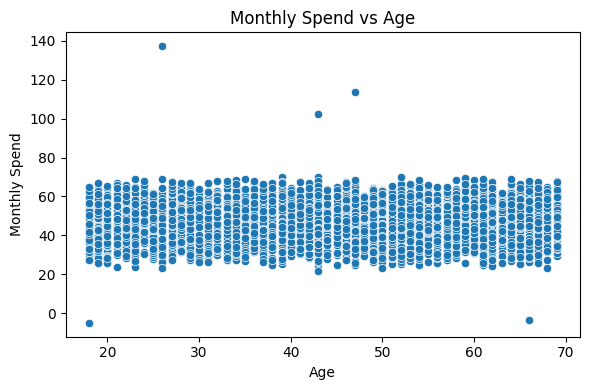

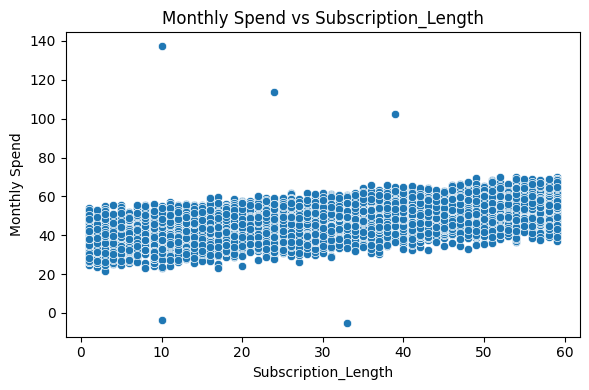

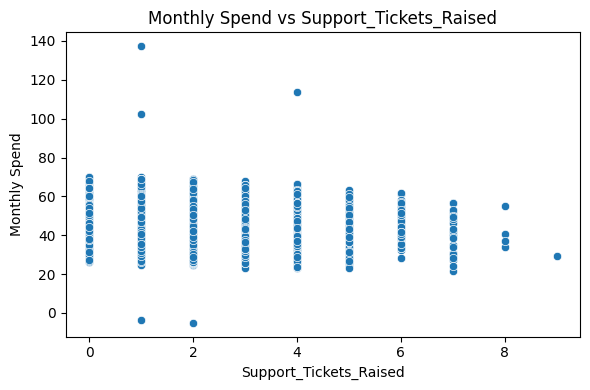

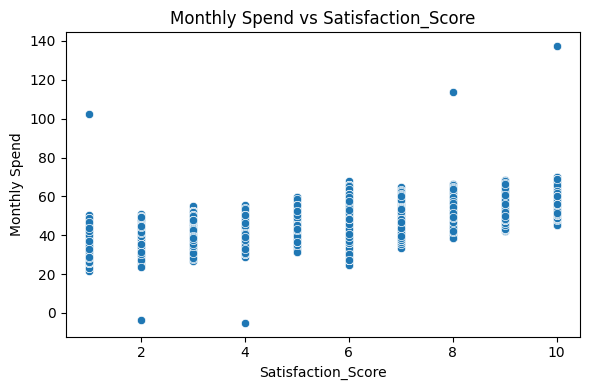

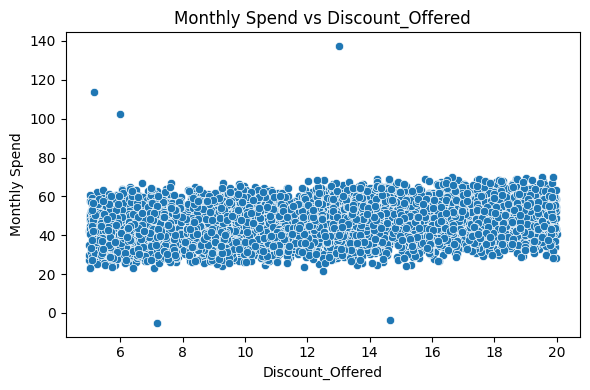

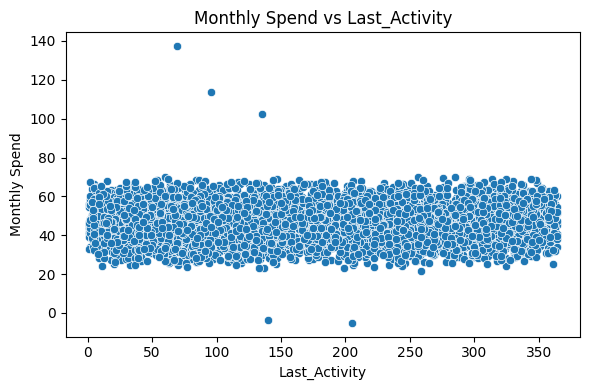

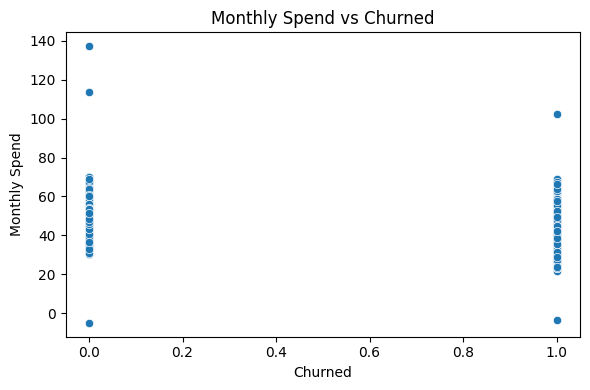

In [ ]:
# the numberic features where plotted against Monthly Spends as so:
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=streaming_df, x=feature, y='Monthly_Spend')
    plt.title(f'Monthly Spend vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Monthly Spend')
    plt.tight_layout()
    plt.show()

**Performing a correlation analysis of monthly spend and other numeric features using a heatmap**

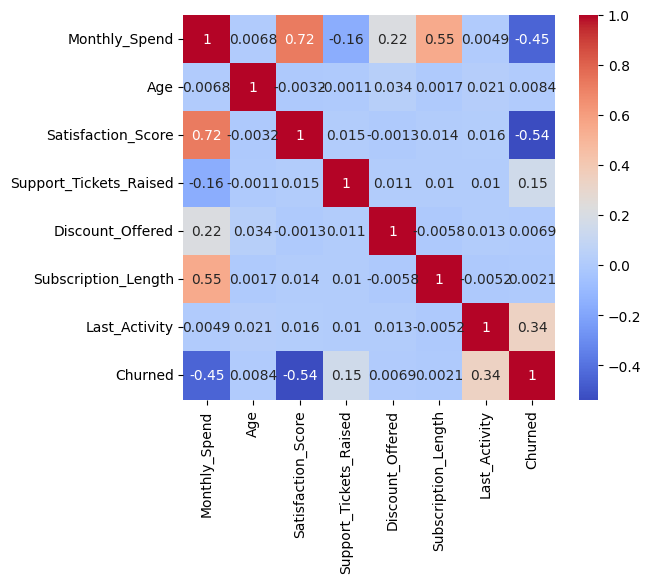

In [ ]:
# Selecting relevant numerical features for correlation analysis
column_list = ["Monthly_Spend", "Age", "Satisfaction_Score", "Support_Tickets_Raised",
               "Discount_Offered", "Subscription_Length", "Last_Activity", "Churned"]


# Creating the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(streaming_df[column_list].corr(), annot=True, cmap="coolwarm")

# Plotting and saving the figure
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

**Building a linear regression model (Training and testing the data)**

It is clear that satisfaction score has the highest correlation to the monthly spend according to the heat map, followed by subscription length, and 'Discount_Offered'. Let’s
build a Simple Linear Regression model in which  satisfaction score predicts Monthly Spend
.  

In [ ]:
#Extract data from pandas data frame:
x = streaming_df["Satisfaction_Score"]
y = streaming_df["Monthly_Spend"]

#Reshaping the data to be suitable for Skilearn
x = x.to_numpy().reshape(-1, 1)

In [ ]:
# Splitting the data into test and train using skilearn library as so training 80% testing 20%

x_train, x_test, y_train, y_test = train_test_split(x, y,
test_size = 0.2, random_state = 42)
print("There are %d data points in the training set." %
(len(x_train), ))
print("There are %d data points in the testing set." %
(len(x_test), ))

There are 4000 data points in the training set.
There are 1000 data points in the testing set.


**Applying standardization to the input features**

In [ ]:
#Applying standardization to the input features so they have a mean of 0 and a standard diviation of 1
#Creating an instance for standardscaler
scale = StandardScaler()

#fit scale to the data in x. It allows it to determine the mean and the standard deviation
scale.fit(x)

#Transform the test and train data:
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

In [ ]:
#creating an instance for the training model
spend_model = LinearRegression()

#fitting the training data
spend_model.fit(x_train_scaled, y_train)

#defining the gradient and intercept
gradient = spend_model.coef_[0]
intercept = spend_model.intercept_

print("gradient: ", gradient)
print("intercept: ", intercept)

gradient:  6.8701271208618
intercept:  46.555074874582694


**Calculating Evaluation Metrics**

In [ ]:
#importing relevant libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#calculating the predicted outputs from the test dataset using the model.
y_pred = spend_model.predict(x_test_scaled)

# Calculating the mean absolute error
mean_abs = mean_absolute_error(y_test, y_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, y_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, y_pred)

print("MAE: ", mean_abs)
print("MSE: ", mean_squared)
print("RMSE: ", rms_error)
print("R2: ", R2)

MAE:  5.1603353681596476
MSE:  42.08439881263931
RMSE:  6.487248940239561
R2:  0.5344674535735893


**Fitting a line through the plot**

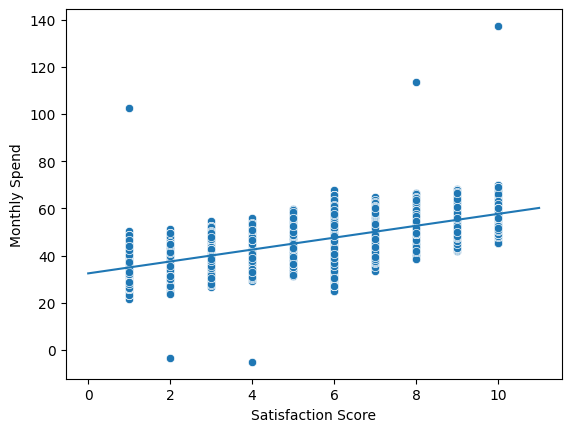

In [ ]:
#Create an array of values covering the range of satisfaction score  from 0 to 12
#shaping it to a 2-dimension array
x_fit = np.arange(0, 12, 1).reshape(-1, 1)
# Applying standardisation transformation
x_fit_scaled = scale.transform(x_fit)
# Apply the trained model to scaled input array to produce best fit line for the y-values
y_fit = spend_model.predict(x_fit_scaled)
# Create a scatter plot of monthly spend vs satisfaction score using seaborn
sns.scatterplot(data = streaming_df, x = "Satisfaction_Score", y = "Monthly_Spend")

# Plotting the best-fit line from trained model
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Satisfaction Score")
plt.ylabel("Monthly Spend")

# Show the plot
plt.show()

**Doing the same process from 'Subscription_Length' as it is the second most correlated with 'Monthly_Spend' in the heat map**

In [ ]:
#Extracting data from pandas data frame:
x = streaming_df["Subscription_Length"]
y = streaming_df["Monthly_Spend"]

#Reshape the data to be suitable for Skilearn from pandas data frame
x = x.to_numpy().reshape(-1, 1)

#Splitting the data into test and train using skilearn library as so training 80% testing 20%:

x_train, x_test, y_train, y_test = train_test_split(x, y,
test_size = 0.2, random_state = 42)
print("There are %d data points in the training set." %
(len(x_train), ))
print("There are %d data points in the testing set." %
(len(x_test), ))

#Applying standardization to the input features so they have a mean of 0 and a standard diviation of 1

#Creating an instance for standardscaler
scale = StandardScaler()

#fitting scale to the data in x. It allows it to determine the mean and the standard deviation:
scale.fit(x)

#Tranforming the test and train data:
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

#creating an instance for the model
spend_model = LinearRegression()

#fitting the training data
spend_model.fit(x_train_scaled, y_train)

#defining the gradient and intercept
gradient = spend_model.coef_[0]
intercept = spend_model.intercept_

print("gradient: ", gradient)
print("intercept: ", intercept)

There are 4000 data points in the training set.
There are 1000 data points in the testing set.
gradient:  5.263237406525985
intercept:  46.62676397417948


In [ ]:
#Calculating evaluation metrics

#calculating the predicted outputs from the test dataset using the model.
y_pred = spend_model.predict(x_test_scaled)

# Calculating the mean absolute error
mean_abs = mean_absolute_error(y_test, y_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, y_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, y_pred)

print("MAE: ", mean_abs)
print("MSE: ", mean_squared)
print("RMSE: ", rms_error)
print("R2: ", R2)

MAE:  6.642846985599881
MSE:  64.8278293332412
RMSE:  8.051573096807928
R2:  0.28288236685617885


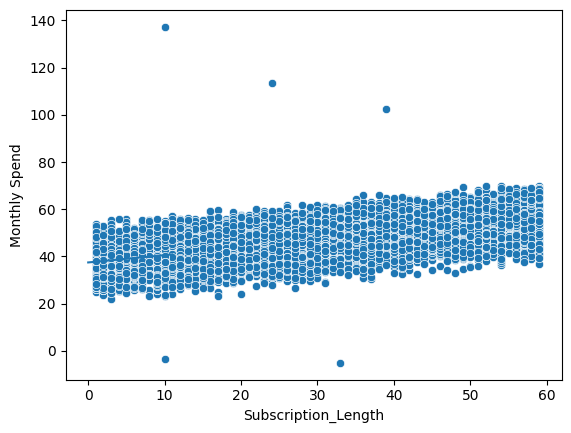

In [ ]:
#Create an array of values covering the range of satisfaction score  from 0 to 12
#shaping it to a 2-dimension array
x_fit = np.arange(0, 12, 1).reshape(-1, 1)
# Applying standardisation transformation
x_fit_scaled = scale.transform(x_fit)
# Apply the trained model to scaled input array to produce best fit line for the y-values
y_fit = spend_model.predict(x_fit_scaled)
# Create a scatter plot of monthly spend vs satisfaction score using seaborn
sns.scatterplot(data = streaming_df, x = "Subscription_Length", y = "Monthly_Spend")

# Plotting the best-fit line from trained model
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Subscription_Length")
plt.ylabel("Monthly Spend")

# Show the plot
plt.show()

**Doing the same process from 'Discount_Offered' as it is the third most correlated with 'Monthly_Spend' in the heat map**

In [ ]:
#Extracting data from pandas data frame:
x = streaming_df["Discount_Offered"]
y = streaming_df["Monthly_Spend"]

#Reshape the data to be suitable for Skilearn from pandas data frame
x = x.to_numpy().reshape(-1, 1)

#Splitting the data into test and train using skilearn library as so training 80% testing 20%:

x_train, x_test, y_train, y_test = train_test_split(x, y,
test_size = 0.2, random_state = 42)
print("There are %d data points in the training set." %
(len(x_train), ))
print("There are %d data points in the testing set." %
(len(x_test), ))

#Applying standardization to the input features so they have a mean of 0 and a standard diviation of 1
from sklearn.preprocessing import StandardScaler

#Creating an instance for standardscaler
scale = StandardScaler()

#fitting scale to the data in x. It allows it to determine the mean and the standard deviation:
scale.fit(x)

#Tranforming the test and train data:
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

#creating an instance for the model
spend_model = LinearRegression()

#fitting the training data
spend_model.fit(x_train_scaled, y_train)

#defining the gradient and intercept
gradient = spend_model.coef_[0]
intercept = spend_model.intercept_

print("gradient: ", gradient)
print("intercept: ", intercept)

There are 4000 data points in the training set.
There are 1000 data points in the testing set.
gradient:  2.0729860128482125
intercept:  46.56108372461377


In [ ]:
#Calculating evaluation metrics

#calculating the predicted outputs from the test dataset using the model.
y_pred = spend_model.predict(x_test_scaled)

# Calculating the mean absolute error
mean_abs = mean_absolute_error(y_test, y_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, y_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, y_pred)

print("MAE: ", mean_abs)
print("MSE: ", mean_squared)
print("RMSE: ", rms_error)
print("R2: ", R2)

MAE:  7.421163720217704
MSE:  86.36949207328912
RMSE:  9.293518820839022
R2:  0.044591090455157634


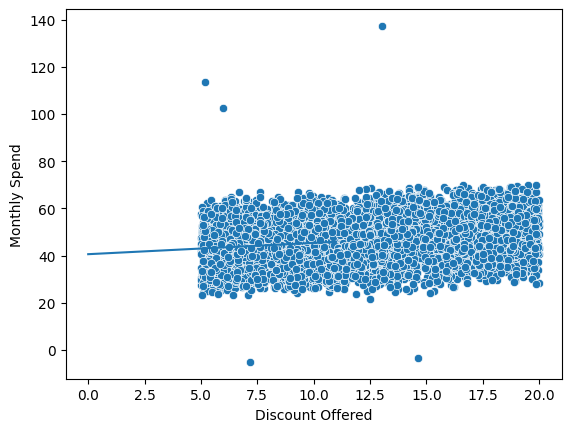

In [ ]:
#Create an array of values covering the range of satisfaction score  from 0 to 12
#shaping it to a 2-dimension array
x_fit = np.arange(0, 12, 1).reshape(-1, 1)
# Applying standardisation transformation
x_fit_scaled = scale.transform(x_fit)
# Apply the trained model to scaled input array to produce best fit line for the y-values
y_fit = spend_model.predict(x_fit_scaled)
# Create a scatter plot of monthly spend vs satisfaction score using seaborn
sns.scatterplot(data = streaming_df, x = "Discount_Offered", y = "Monthly_Spend")

# Plotting the best-fit line from trained model
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Discount Offered")
plt.ylabel("Monthly Spend")

# Show the plot
plt.show()

**Training a linear regression model that evaluates numeric features singlularly**

In [ ]:
# a variable containing a list of all numeric features
numerical_features = ['Age', 'Subscription_Length', 'Support_Tickets_Raised',
                      'Satisfaction_Score', 'Discount_Offered', 'Last_Activity', 'Churned']

results = {}

for feature in numerical_features:
    X = streaming_df[[feature]].values
    y = streaming_df['Monthly_Spend'].values

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # Fit linear regression
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[feature] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
results_df.columns = ['Feature', 'MAE', 'MSE', 'RMSE', 'R2']

results_df

,Feature,MAE,MSE,RMSE,R2
0,Age,7.641336,90.481371,9.512170,-0.000894
1,Subscription_Length,6.642847,64.827829,8.051573,0.282882
2,Support_Tickets_Raised,7.600181,88.795027,9.423111,0.017760
3,Satisfaction_Score,5.160335,42.084399,6.487249,0.534467
4,Discount_Offered,7.421164,86.369492,9.293519,0.044591
5,Last_Activity,7.641970,90.490906,9.512671,-0.000999
6,Churned,6.839265,73.979788,8.601150,0.181645


**Polynomial Regression Model**

In [ ]:
# Secondly I will fit a polynomial regression model for each feature to compare performance of linear vs polynomial.
# Extract the input feature
x = streaming_df["Satisfaction_Score"]
# Extract the output feature
y = streaming_df["Monthly_Spend"]
# reshaping x to 2 dimensions.
x = x.to_numpy().reshape(-1, 1)
# Splitting the x and y data between the training and testing datasets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Creating an instance of the StandardScaler class
scale = StandardScaler()
# Fitting the standard scaler to the input data that in x_train.
scale.fit(x_train)
#transforming the standard scaled test and train data set
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

In [ ]:
# creating the polynomial features like so:
poly = PolynomialFeatures(degree = 2, include_bias = False)

# applying the Polynomial Features transformation to the scaled input data from the training set.
x_poly = poly.fit_transform(x_train_scaled)

#Creating an instance of the LinearRegression model.
streaming_poly = LinearRegression()
# Fitting the model to the training data.
streaming_poly.fit(x_poly, y_train)

# Getting the fit coefficients from the best-fit model.
coefficients = streaming_poly.coef_
intercept = streaming_poly.intercept_

# Printing the coefficients
print("coefficients: ", coefficients)
print("intercept: ", intercept)

coefficients:  [6.86475443 0.15762151]
intercept:  46.40526849378567


In [ ]:
#calculating the evaluation metrics
x_test_poly = poly.fit_transform(x_test_scaled)
y_pred = streaming_poly.predict(x_test_poly)

# Calculating the mean absolute error
mean_abs = mean_absolute_error(y_test, y_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, y_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, y_pred)

print("MAE: ", mean_abs)
print("MSE: ", mean_squared)
print("RMSE: ", rms_error)
print("R2: ", R2)

MAE:  5.161274443263781
MSE:  42.07980871270453
RMSE:  6.486895151974058
R2:  0.5345182287057351


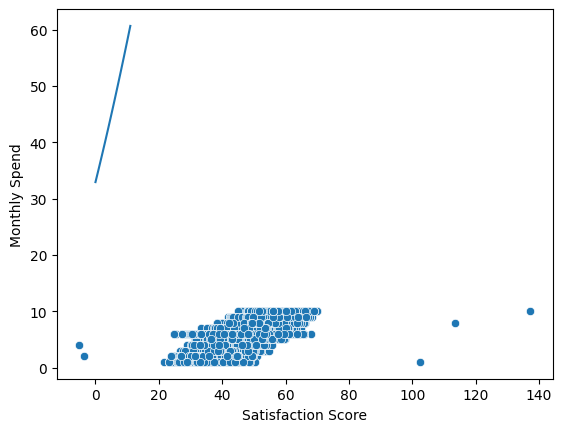

In [ ]:
# Create an array of values covering the range of 0 to 12 to fit satisfactory score
x_fit = np.arange(0, 12, 1).reshape(-1, 1)

# Apply the standardisation transformation
x_fit_scaled = scale.transform(x_fit)
# Creating the polyomial features and applying them to the trained model
x_fit_poly = poly.fit_transform(x_fit_scaled)
y_fit = streaming_poly.predict(x_fit_poly)

# Creating a scatter plot for Monthlly Spends vs Satisfaction Score
sns.scatterplot(data = streaming_df, x = "Monthly_Spend", y = "Satisfaction_Score")
# Plot the best-fit line from
# the trained model
plt.plot(x_fit, y_fit)
# Label both axes
plt.xlabel("Satisfaction Score")
plt.ylabel("Monthly Spend")
# Show the plot
plt.show()

**repeating same for Monthly Spend and Subscription Length**

In [ ]:
# Extract the input feature
x = streaming_df["Subscription_Length"]
# Extract the output feature
y = streaming_df["Monthly_Spend"]
# reshaping x to 2 dimensions.
x = x.to_numpy().reshape(-1, 1)
# Splitting the x and y data between the training and testing datasets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Creating an instance of the StandardScaler class
scale = StandardScaler()
# Fitting the standard scaler to the input data that in x_train.
scale.fit(x_train)
#transforming the standard scaled test and train data set
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

# create the polynomial features like so:
poly = PolynomialFeatures(degree = 2, include_bias = False)

# applying the Polynomial Features transformation to the scaled input data from the training set.
x_poly = poly.fit_transform(x_train_scaled)

#Creating an instance of the LinearRegression model.
streaming_poly = LinearRegression()
# Fitting the model to the training data.
streaming_poly.fit(x_poly, y_train)

# Getting the fit coefficients from the best-fit model.
coefficients = streaming_poly.coef_
intercept = streaming_poly.intercept_

# Printing the coefficients
print("coefficients: ", coefficients)
print("intercept: ", intercept)

#calculating the evaluation metrics
x_test_poly = poly.fit_transform(x_test_scaled)
y_pred = streaming_poly.predict(x_test_poly)

# Calculating the mean absolute error
mean_abs = mean_absolute_error(y_test, y_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, y_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, y_pred)

print("MAE: ", mean_abs)
print("MSE: ", mean_squared)
print("RMSE: ", rms_error)
print("R2: ", R2)

coefficients:  [5.23236512 0.12269526]
intercept:  46.44019474212136
MAE:  6.645539420307651
MSE:  64.90630095376105
RMSE:  8.05644468445983
R2:  0.28201432324967635


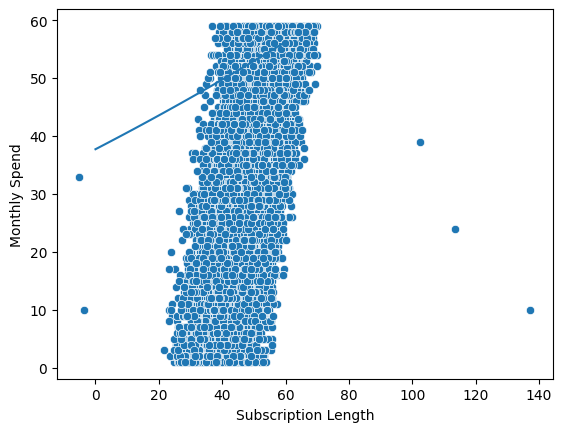

In [ ]:
# Creating an array of values covering the range of 0 to 12 to fit satisfactory score
x_fit = np.arange(0, 60, 1).reshape(-1, 1)

# Applying the standardisation transformation
x_fit_scaled = scale.transform(x_fit)
# Creating the polyomial features and applying them to the trained model
x_fit_poly = poly.fit_transform(x_fit_scaled)
y_fit = streaming_poly.predict(x_fit_poly)

# Creating a scatter plot for Monthlly Spends vs Satisfaction Score
sns.scatterplot(data = streaming_df, x = "Monthly_Spend", y = "Subscription_Length")
# Plotting the best-fit line from the trained model
plt.plot(x_fit, y_fit)
# Label both axes
plt.xlabel("Subscription Length")
plt.ylabel("Monthly Spend")
# Show the plot
plt.show()

**Doing a polynomial regression for "Discount Offered"**

In [ ]:
# Extract the input feature
x = streaming_df["Discount_Offered"]
# Extract the output feature
y = streaming_df["Monthly_Spend"]
# reshaping x to 2 dimensions.
x = x.to_numpy().reshape(-1, 1)
# Splitting the x and y data between the training and testing datasets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Creating an instance of the StandardScaler class
scale = StandardScaler()
# Fitting the standard scaler to the input data that in x_train.
scale.fit(x_train)
#transforming the standard scaled test and train data set
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

# create the polynomial features like so:
poly = PolynomialFeatures(degree = 2, include_bias = False)

# applying the Polynomial Features transformation to the scaled input data from the training set.
x_poly = poly.fit_transform(x_train_scaled)

#Creating an instance of the LinearRegression model.
streaming_poly = LinearRegression()
# Fitting the model to the training data.
streaming_poly.fit(x_poly, y_train)

# Getting the fit coefficients from the best-fit model.
coefficients = streaming_poly.coef_
intercept = streaming_poly.intercept_

# Printing the coefficients
print("coefficients: ", coefficients)
print("intercept: ", intercept)

#calculating the evaluation metrics
x_test_poly = poly.fit_transform(x_test_scaled)
y_pred = streaming_poly.predict(x_test_poly)

# Calculating the mean absolute error
mean_abs = mean_absolute_error(y_test, y_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, y_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, y_pred)

print("MAE: ", mean_abs)
print("MSE: ", mean_squared)
print("RMSE: ", rms_error)
print("R2: ", R2)

coefficients:  [ 2.06360117 -0.03782345]
intercept:  46.600713445303036
MAE:  7.421170990665346
MSE:  86.36946018286791
RMSE:  9.293517105104392
R2:  0.04459144322315267


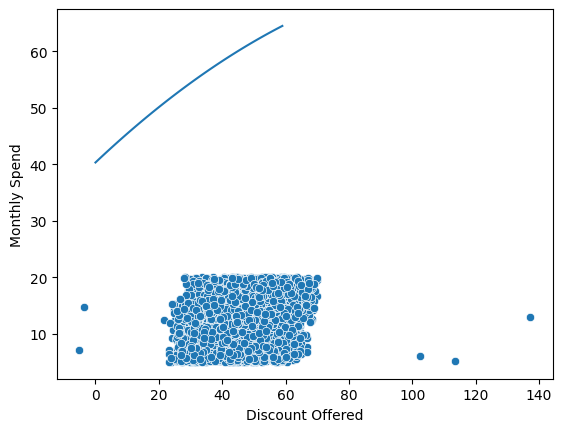

In [ ]:
# Creating an array of values covering the range of 0 to 12 to fit satisfactory score
x_fit = np.arange(0, 60, 1).reshape(-1, 1)

# Apply the standardisation transformation
x_fit_scaled = scale.transform(x_fit)
# Creating the polyomial features and applying them to the trained model
x_fit_poly = poly.fit_transform(x_fit_scaled)
y_fit = streaming_poly.predict(x_fit_poly)

# Creating a scatter plot for Monthlly Spends vs Satisfaction Score
sns.scatterplot(data = streaming_df, x = "Monthly_Spend", y = "Discount_Offered")
# Plot the best-fit line from
# the trained model
plt.plot(x_fit, y_fit)
# Label both axes
plt.xlabel("Discount Offered")
plt.ylabel("Monthly Spend")
# Show the plot
plt.show()

**Creating a poly regression for all numeric features**

In [ ]:
#creating a poly regression for all numeric features

numerical_features = ["Age", "Satisfaction_Score", "Support_Tickets_Raised",
               "Discount_Offered", "Subscription_Length", "Last_Activity", "Churned"]

poly_results = {}

for feature in numerical_features:
    X = streaming_df[[feature]].values
    y = streaming_df['Monthly_Spend'].values

    # Split and scale
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Polynomial features (degree=2)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # Fit polynomial regression
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)

    # Getting the fit coefficients from the best-fit model.
    coefficients = model.coef_
    intercept = model.intercept_

    # Printing the coefficients
    print("coefficients: ", coefficients)
    print("intercept: ", intercept)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    poly_results[feature] = {'Poly_MAE': mae, 'Poly_MSE': mse, 'Poly_RMSE': rmse, 'Poly_R2': r2}

# Convert to DataFrame
poly_metrics_df = pd.DataFrame.from_dict(poly_results, orient='index').reset_index()
poly_metrics_df.columns = ['Feature', 'Poly_MAE', 'Poly_MSE', 'Poly_RMSE', 'Poly_R2']

poly_metrics_df

coefficients:  [ 0.00014564 -0.01957833]
intercept:  46.58246832852727
coefficients:  [6.86475443 0.15762151]
intercept:  46.40526849378567
coefficients:  [-1.72185586  0.18499112]
intercept:  46.37789887533191
coefficients:  [ 2.06360117 -0.03782345]
intercept:  46.600713445303036
coefficients:  [5.23236512 0.12269526]
intercept:  46.44019474212136
coefficients:  [-0.01565999  0.02204516]
intercept:  46.54084483968572
coefficients:  [-4.11538514 -0.88996508]
intercept:  47.45285507807453


,Feature,Poly_MAE,Poly_MSE,Poly_RMSE,Poly_R2
0,Age,7.641334,90.471726,9.511663,-0.000787
1,Satisfaction_Score,5.161274,42.079809,6.486895,0.534518
2,Support_Tickets_Raised,7.605874,88.918710,9.429672,0.016392
3,Discount_Offered,7.421171,86.369460,9.293517,0.044591
4,Subscription_Length,6.645539,64.906301,8.056445,0.282014
5,Last_Activity,7.641044,90.484097,9.512313,-0.000924
6,Churned,6.839265,73.979788,8.601150,0.181645


**(b)** Consider regression models that take multiple numerical variables as input features to
predict "Monthly Spend". Does including multiple features improve prediction accuracy
compared to single-variable models from part (a)?

**Multiple Linear Regression**

**Plotting Multiple Linear Regression for most correlated features to monthly spend**

In [ ]:
# Extract features and target
x = streaming_df[['Satisfaction_Score', 'Discount_Offered', 'Subscription_Length']]
y = streaming_df['Monthly_Spend']

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Standardize features
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.transform(x_test)

# Train model
model = LinearRegression()
model.fit(x_train_scaled, y_train)

# Predict
y_pred = model.predict(x_test_scaled)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# Print coefficients for each feature
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Mean Absolute Error: 2.0081364265532433
Mean Squared Error: 12.423943582083293
Root Mean Squared Error: 3.5247614929358404
R2 Score: 0.8625678337909808
Coefficients: [6.78127844 2.10298123 5.11936686]
Intercept: 46.562889999999996


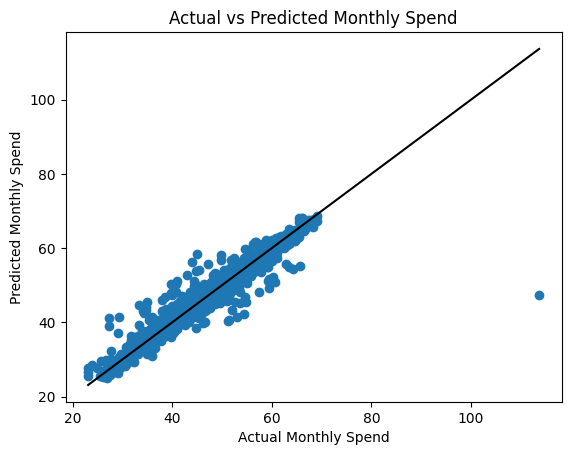

In [ ]:
# Creating a scatterplot of actual vs predicted Monthly Spend
plt.scatter(y_test, y_pred)

# Adding a straight diagonal line to show perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k-')

# Labeling the axes
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")

# Adding a title
plt.title("Actual vs Predicted Monthly Spend")

# Show the plot
plt.show()

**Creating a multiple Linear Regression for all numeric features**

In [ ]:
# Extract features and target
x = streaming_df[numerical_features]
y = streaming_df['Monthly_Spend']

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Standardize features
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.transform(x_test)

# Train model
model = LinearRegression()
model.fit(x_train_scaled, y_train)

# Predict
y_pred = model.predict(x_test_scaled)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# Print coefficients for each feature
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Mean Absolute Error: 1.422650380155529
Mean Squared Error: 10.105446360512913
Root Mean Squared Error: 3.1789064724387397
R2 Score: 0.8882147705630954
Coefficients: [ 6.28682201e-03  6.47794806e+00 -1.67115404e+00  2.11030554e+00
  5.14948319e+00  1.40604687e-01 -6.00158834e-01]
Intercept: 46.562889999999996


**Creating a scatter plot comparing the predicted and actual values of the predicted variables**

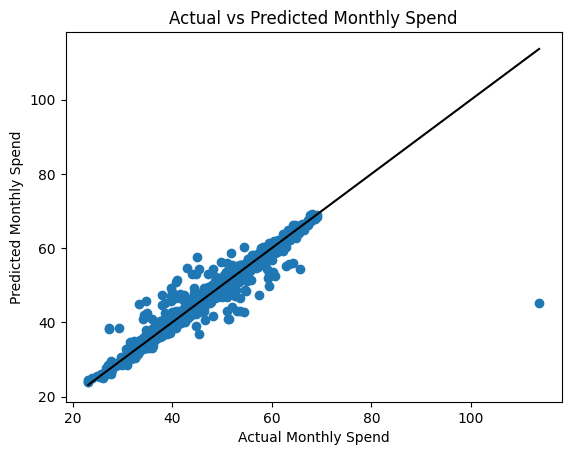

In [ ]:
# Creating a scatterplot of actual vs predicted Monthly Spend
plt.scatter(y_test, y_pred)

# Adding a straight diagonal line to show perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k-')

# Labeling the axes
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")

# Adding a title
plt.title("Actual vs Predicted Monthly Spend")

# Show the plot
plt.show()

**(c)** In parts (a) and (b), you only considered numerical variables as input. However, several
categorical variables (e.g., Gender, Region, Payment_Method) might also affect Monthly
Spend. Now train a regression model that uses both categorical and numerical variables (e.g.,
a Random Forest Regressor). Does this improve the model’s performance?  

**Training a Random Forest Regressor using both numerical and categorical features**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor


# Defining numerical and categorical features for modeling

numerical_features = [ "Age", "Satisfaction_Score", "Support_Tickets_Raised",
               "Discount_Offered", "Subscription_Length", "Last_Activity", "Churned"]
categorical_features = ['Gender', 'Region', 'Payment_Method']

#  Creating a copy of the DataFrame for encoding categorical variables
df_encoded = streaming_df.copy()

# Labeling encode categorical features to convert them into numeric format for the model
for col in categorical_features:
    label = LabelEncoder()
    df_encoded[col] = label.fit_transform(df_encoded[col])

# Combining numerical and encoded categorical features as input
X = df_encoded[numerical_features + categorical_features]
y = df_encoded['Monthly_Spend']

# Splitting dataset into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features for models that require it
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Initializing and train Random Forest Regressor on unscaled data
model = RandomForestRegressor(random_state=42)
model.fit(x_train, y_train)  # Fixed syntax error: missing line break

# Predicting monthly spend on the test set
y_pred = model.predict(x_test)

# Calculating evaluation metrics to assess model performance
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 1.7185191000000022
MSE: 10.72735648529001
RMSE: 3.2752643382313447
R²: 0.8813352757335555


In [ ]:
print(X.head())

    Age  Satisfaction_Score  Support_Tickets_Raised  Discount_Offered  \
0  56.0                 9.0                       0              6.42   
1  69.0                 2.0                       1             13.77   
2  46.0                 8.0                       3             19.91   
3  32.0                 1.0                       3             13.39   
4  60.0                 6.0                       2             13.18   

   Subscription_Length  Last_Activity  Churned  Gender  Region  Payment_Method  
0                   54            319        1       1       2               2  
1                   21            166        1       0       0               1  
2                   49            207        0       0       0               2  
3                   47            108        1       1       3               1  
4                    6             65        0       1       0               0  


**(d)** Develop an Artificial Neural Network (ANN) model to predict Monthly Spend based on all
available features in the dataset. How does its performance compare to other supervised
learning models? Discuss your neural network architecture, hyperparameter tuning, and
optimization choices.

**Developing Artifical Neural Network to predict Monthly_Spend**

**Extracting input and output feature**

In [ ]:
# Extracting the input features called 'x'
x = X

# Extracting the output features called 'y'.
y = streaming_df["Monthly_Spend"]

**Splitting testing and training dataset**

In [ ]:
# Split between train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

print("There are %d data points in the training set." %
(len(x_train), ))
print("There are %d data points in the testing set." %
(len(x_test), ))

There are 4000 data points in the training set.
There are 1000 data points in the testing set.


**Rescaling variables using min-max scaler**

In [ ]:
# Importing the MinMaxScaler class from sklearn
from sklearn.preprocessing import MinMaxScaler

# Creating an instantiating of the MinMaxScaler class
scale = MinMaxScaler()

# Fitting the min-max scaler to the input data in x_train to find minimium and maximium values
scale.fit(x_train)

MinMaxScaler()

**Rescaling and transforming dataset**

In [ ]:
#rescaking and transforming dataset
x_train_scaled = scale.transform(x_train)
 x_test_scaled = scale.transform(x_test)

In [ ]:
x_train_scaled

array([[0.50980392, 0.        , 0.125     , ..., 1.        , 0.66666667,
        0.        ],
       [0.05882353, 0.66666667, 0.125     , ..., 1.        , 1.        ,
        0.        ],
       [0.17647059, 1.        , 0.375     , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.64705882, 0.77777778, 0.125     , ..., 0.        , 0.33333333,
        1.        ],
       [0.01960784, 0.88888889, 0.375     , ..., 0.        , 1.        ,
        0.5       ],
       [0.49019608, 0.33333333, 0.25      , ..., 0.        , 1.        ,
        0.        ]])

In [ ]:
print(x.columns.tolist())

['Age', 'Satisfaction_Score', 'Support_Tickets_Raised', 'Discount_Offered', 'Subscription_Length', 'Last_Activity', 'Churned', 'Gender', 'Region', 'Payment_Method']


In [ ]:
#Importing relevant libraries to build neural network
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

 **Building neural network model - input layer, 2 hidden layers, a dropout layer and an output layer**

In [ ]:
#Creating an instance for sequencial class
model = Sequential()

#Adding three input layers to the model
model.add(Input(shape=(10,)))

#Creating dense hidden layer using RELU
model.add(Dense(units = 64, activation = "relu"))

#creating a 20% drop down layer to prevent over-fitting
model.add(Dropout(0.2))

#Adding the second hidden layer
model.add(Dense(units = 64, activation = "relu"))

#Creating an output layer using linear activation
model.add(Dense(units = 1, activation = "linear"))

#Printing a summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

**Compiling the Model**

In [ ]:
from keras.losses import mean_squared_error #Used for loss function during training
from keras.metrics import mean_squared_error #Evaluates model's performance during training/validation
from tensorflow.keras.optimizers import SGD # importing stochastic gradient descent (SGD)
from tensorflow.keras.optimizers import Adam # importing the adam from the tensorflow

In [ ]:
#compiling model using the Adam Optimizer and specifying loss function
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

print(model)
print(x_train_scaled)
print(y_train)

<Sequential name=sequential, built=True>
[[0.50980392 0.         0.125      ... 1.         0.66666667 0.        ]
 [0.05882353 0.66666667 0.125      ... 1.         1.         0.        ]
 [0.17647059 1.         0.375      ... 0.         0.         1.        ]
 ...
 [0.64705882 0.77777778 0.125      ... 0.         0.33333333 1.        ]
 [0.01960784 0.88888889 0.375      ... 0.         1.         0.5       ]
 [0.49019608 0.33333333 0.25       ... 0.         1.         0.        ]]
4227    39.04
4676    60.74
800     51.74
3671    40.70
4193    48.71
        ...  
4426    39.69
466     33.47
3092    52.80
3772    56.67
860     48.81
Name: Monthly_Spend, Length: 4000, dtype: float64


**Training the Model**

In [ ]:
 # Importing the EarlyStopping class from Keras
 from keras.callbacks import EarlyStopping

In [ ]:
#defining early stopping criterion, monitoring validation loss and an defining patience of 20
early_stopping = EarlyStopping(monitor='val_loss', patience = 20)

#fitting the model with early stopping
history = model.fit(x = x_train_scaled, y = y_train,
batch_size = None, epochs = 200,
verbose = "auto", validation_split = 0.1,
callbacks = [early_stopping])

Epoch 1/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1931.0056 - mean_squared_error: 1931.0056 - val_loss: 121.5767 - val_mean_squared_error: 121.5767
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 117.0326 - mean_squared_error: 117.0326 - val_loss: 38.3815 - val_mean_squared_error: 38.3815
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 49.9621 - mean_squared_error: 49.9621 - val_loss: 16.8667 - val_mean_squared_error: 16.8667
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 35.3670 - mean_squared_error: 35.3670 - val_loss: 11.0195 - val_mean_squared_error: 11.0195
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 24.6629 - mean_squared_error: 24.6629 - val_loss: 8.0560 - val_mean_squared_error: 8.0560
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 27.9951 - mean_squared_error: 27.9951 - val_loss: 7.4558 - val_mean_squared_error: 7.4558
Epoch 7/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26.7085 - mean_sq

In [ ]:
print(x_train_scaled.shape)

(4000, 10)


**Making Predictions**

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


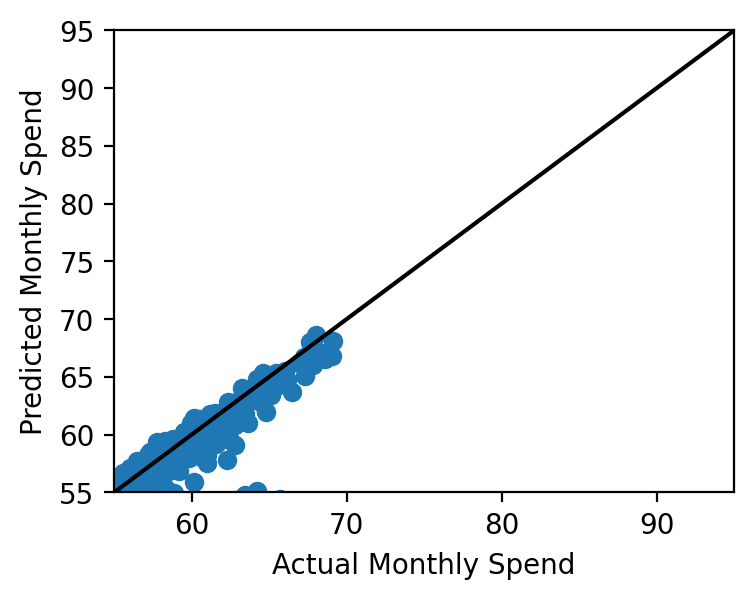

In [ ]:
# Predicting the model outputs for the testing set
y_pred = model.predict(x_test_scaled)

#plotting actual monthly spend versus predicted monthly spend (output)
# Creating a figure
plt.figure(figsize=(4, 3), dpi=200)

#creating a scatter plot for both variables
plt.scatter(y_test, y_pred)

# Add a straight diagonal line to the plot.
 # If the model is performing well, the data
 # points should lie along this line, meaning
 # that the predicted values are equal to the
 # actual values.
plt.plot([55, 95], [55, 95], 'k-')

 # Label both axes.
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")

 # Limit the range of values on both axes
plt.xlim(55, 95)
plt.ylim(55, 95)
 # Show the plot.
plt.savefig("annpred1.png", dpi=300, bbox_inches='tight')
plt.show()

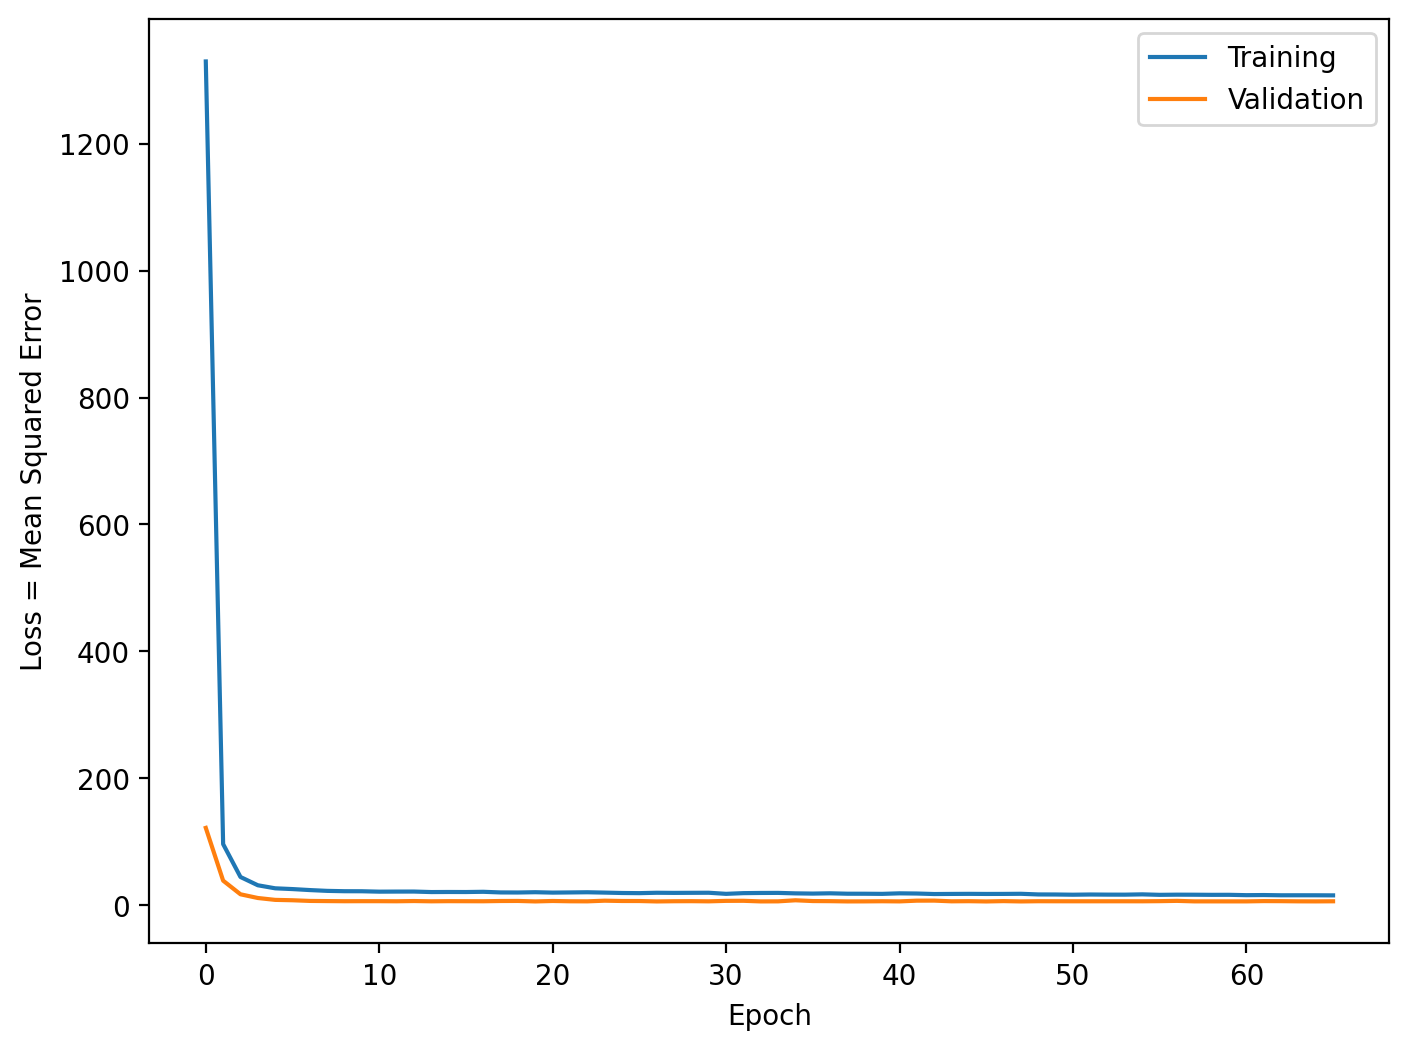

In [ ]:
#plotting how the loss function varies with epoch, for both the training and the validation sets,
#creating a pandas dataframe containing the history of the fitting.

history_df = pd.DataFrame(history.history)

#creating figure
plt.figure(figsize = (8, 6), dpi = 200)

# Plotting the history of the training and validation losses.
plt.plot(history_df["loss"], label = "Training")
plt.plot(history_df["val_loss"], label = "Validation")

# Adding a legend to the plot.
plt.legend()

# Label both axes.
plt.xlabel("Epoch")
plt.ylabel("Loss = Mean Squared Error")

# Show the plot.
plt.savefig("epochgraph.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#The loss mean square error begins somewhere a little below 1600 and for the validation,it
#begins around 200 both starting and dropping at aound 3 epoch.
#Then stopping a bit before 50 epoch

In [ ]:
# Predict on the test set
y_pred = model.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test MAE:", mae)
print("Test R2:", r2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Test MSE: tf.Tensor(
[2.27723062e-01 6.74265087e-01 7.02324066e+01 2.77553182e-02
 2.07439974e-01 1.17968285e+00 8.18643093e-01 1.82148279e-03
 1.63556612e+00 5.05141687e+00 4.09101322e-03 1.93813697e-01
 2.09261298e-01 1.11606725e-01 3.26124966e-01 1.24312663e+00
 3.30279708e+00 2.67482901e+00 5.50559223e-01 3.55528998e+00
 4.10964303e-02 1.89580035e+00 2.65249051e-02 3.95719826e-01
 1.03901625e+00 5.16848326e+00 5.13928123e-02 6.85715199e-01
 2.08097234e-01 2.60803044e-01 4.58756828e+01 4.70389351e-02
 7.19653308e-01 3.34772015e+00 1.25400460e+00 5.33434391e+00
 7.98112810e-01 3.51136178e-01 2.59667349e+00 2.65613246e+00
 2.37376639e-03 4.14077425e+00 7.97901297e+00 2.24503589e+00
 1.44093952e+01 1.65587807e+01 4.38686907e-01 1.50191128e+00
 2.71981168e+00 2.14985943e+00 3.87460470e-01 6.08629137e-02
 4.61004861e-02 4.67315006e+00 9.17647421e-01 5.90770149e+00
 3.31944251e+00 1.83804017e-02 1.27153704e-04 2.02789497e+00
 4.85116005e-01 2.137839

**Tuning by adding a third hidden layer**

In [ ]:
#Creating an instance for sequencial class
model = Sequential()

#Adding input layer wish shape = 10 to the model
model.add(Input(shape=(10,)))

#Creating dense hidden layer using RELU
model.add(Dense(units = 64, activation = "relu"))

#creating a 20% drop down layer to prevent over-fitting
model.add(Dropout(0.2))

#Adding the second hidden layer
model.add(Dense(units = 64, activation = "relu"))

#Adding a third hidden layer
model.add(Dense(units = 64, activation = "relu"))

#Creating an output layer using linear activation
model.add(Dense(units = 1, activation = "linear"))

#Printing a summary of the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compiling model using the Adam Optimizer and specifying loss function
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

#defining early stopping criterion, monitoring validation loss and an defining patience of 20
early_stopping = EarlyStopping(monitor='val_loss', patience = 20)

#fitting the model with early stopping
history = model.fit(x = x_train_scaled, y = y_train,
batch_size = None, epochs = 200,
verbose = "auto", validation_split = 0.1,
callbacks = [early_stopping])

Epoch 1/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 1475.3232 - mean_squared_error: 1475.3232 - val_loss: 44.0484 - val_mean_squared_error: 44.0484
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 51.0162 - mean_squared_error: 51.0162 - val_loss: 11.0799 - val_mean_squared_error: 11.0799
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 29.7610 - mean_squared_error: 29.7610 - val_loss: 7.1369 - val_mean_squared_error: 7.1369
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 22.6063 - mean_squared_error: 22.6063 - val_loss: 9.3362 - val_mean_squared_error: 9.3362
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 22.8620 - mean_squared_error: 22.8620 - val_loss: 6.1214 - val_mean_squared_error: 6.1214
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 23.0393 - mean_squared_error: 23.0393 - val_loss: 6.1622 - val_mean_squared_error: 6.1622
Epoch 7/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 18.8909 - mean_squared_e

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


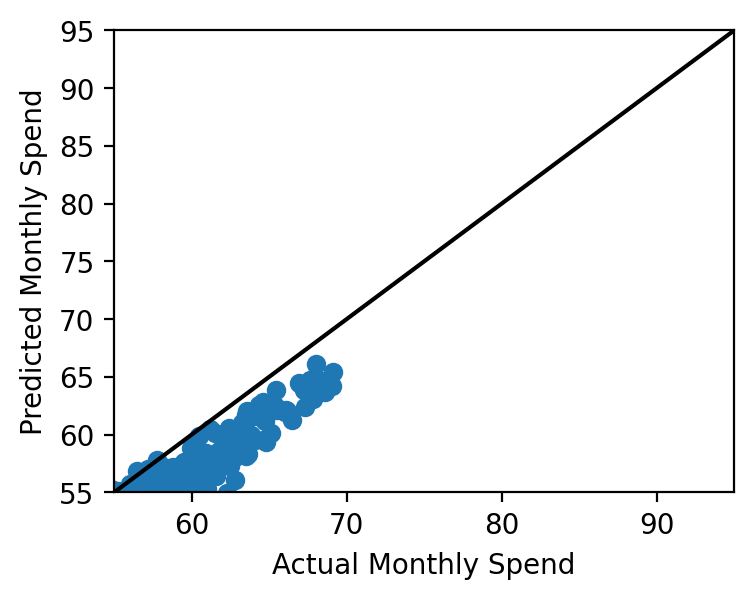

In [ ]:
# Predicting the model outputs for the testing set
y_pred = model.predict(x_test_scaled)

#plotting actual monthly spend versus predicted monthly spend (output)
# Creating a figure
plt.figure(figsize=(4, 3), dpi=200)

#creating a scatter plot for both variables
plt.scatter(y_test, y_pred)

# Add a straight diagonal line to the plot.
 # If the model is performing well, the data
 # points should lie along this line, meaning
 # that the predicted values are equal to the
 # actual values.
plt.plot([55, 95], [55, 95], 'k-')

 # Label both axes.
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")

 # Limit the range of values on both axes
plt.xlim(55, 95)
plt.ylim(55, 95)
 # Show the plot.
plt.savefig("annpred2.png", dpi=300, bbox_inches='tight')
plt.show()

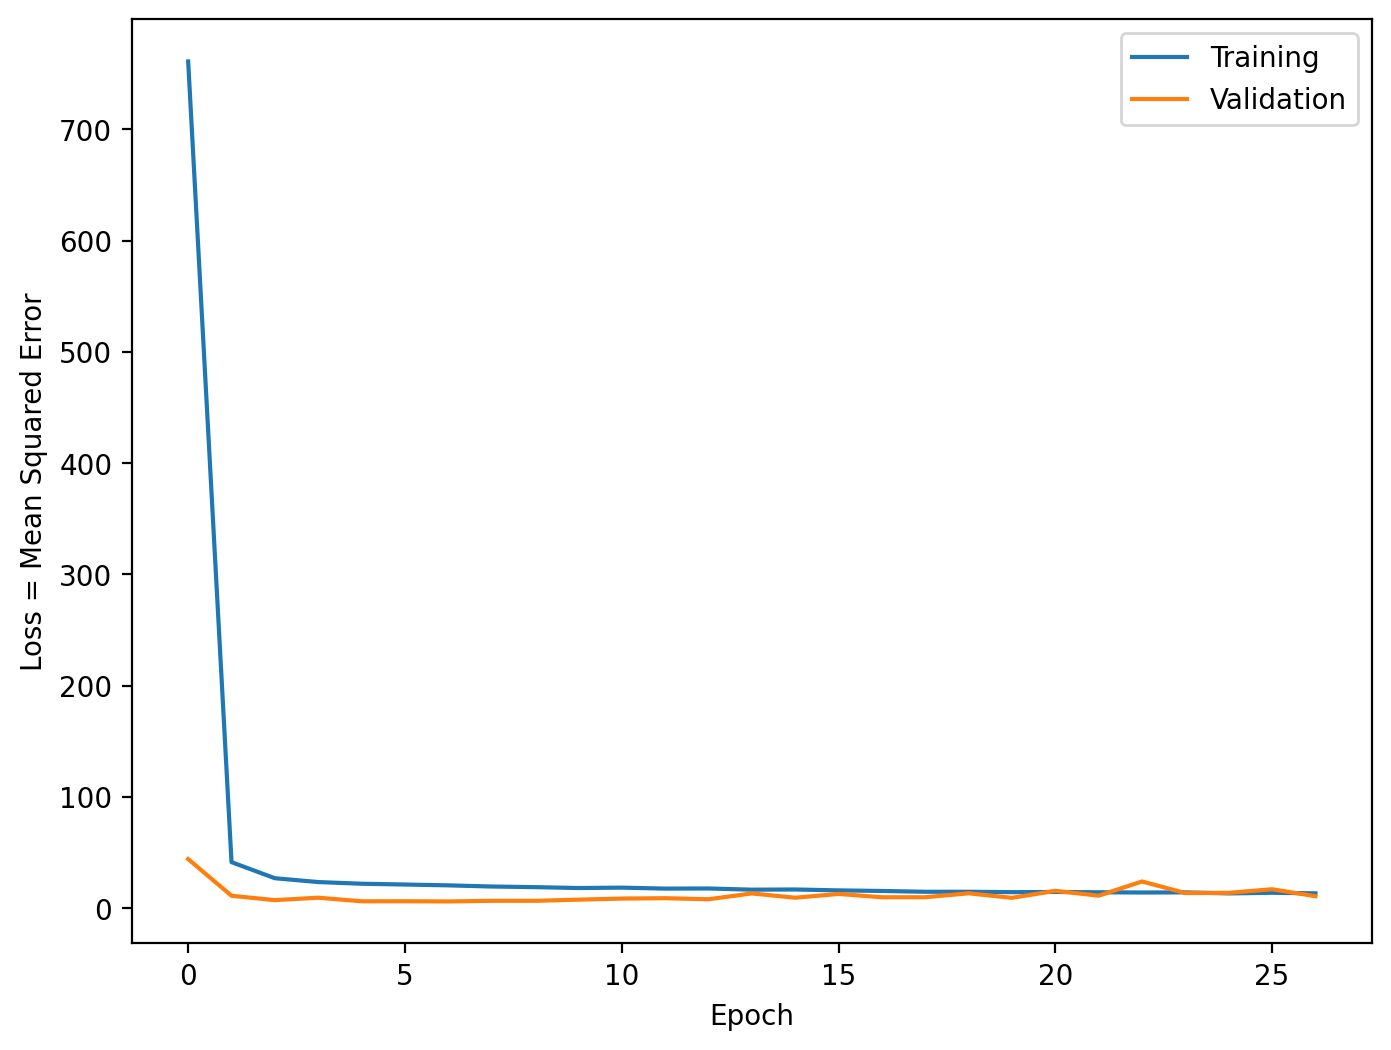

In [ ]:
#plotting how the loss function varies with epoch, for both the training and the validation sets,
#creating a pandas dataframe containing the history of the fitting.

history_df = pd.DataFrame(history.history)

#creating figure
plt.figure(figsize = (8, 6), dpi = 200)

# Plotting the history of the training and validation losses.
plt.plot(history_df["loss"], label = "Training")
plt.plot(history_df["val_loss"], label = "Validation")

# Adding a legend to the plot.
plt.legend()

# Label both axes.
plt.xlabel("Epoch")
plt.ylabel("Loss = Mean Squared Error")

# Show the plot.
plt.savefig("epoch 2.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#The loss mean square error begins somewhere a little over 800 and for the validation,it
#begins around 50 both starting and dropping at aound 3 epoch.
#Then stopping at just before 30 epoch

In [ ]:
# Predict on the test set
y_pred = model.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test MAE:", mae)
print("Test R2:", r2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Test MSE: tf.Tensor(
[1.63170452e+01 6.46831512e-01 5.28466949e+01 2.74162561e-01
 2.97500110e+00 7.95680952e+00 5.91510248e+00 7.42004439e-03
 2.06042242e+00 1.35224752e+01 2.03846908e+00 2.80101113e-02
 8.93798828e+00 1.86471915e+00 6.30482391e-05 1.22328625e+01
 6.16152811e+00 4.17794657e+00 7.26824665e+00 2.15206738e+01
 2.08732963e+00 3.44709039e+00 5.14514637e+00 7.89442778e-01
 1.82311118e-01 7.43845711e-03 5.12778616e+00 1.86193848e+00
 3.53916764e+00 4.20858335e+00 6.98036575e+01 1.33911157e+00
 1.02846336e+01 9.90318954e-01 1.01857913e+00 2.24569855e+01
 5.81890345e-01 3.71401286e+00 8.99040282e-01 1.41489496e+01
 5.53336334e+00 1.92197132e+01 2.87907333e+01 1.29888716e+01
 1.62373543e+01 3.85429115e+01 4.05684114e-06 2.29425240e+00
 1.19880190e+01 1.05079956e+01 7.91837645e+00 1.09450209e+00
 1.51335871e+00 2.07684326e+01 7.31252551e-01 2.36089287e+01
 1.90063457e+01 4.98680234e-01 2.81629038e+00 1.28198824e+01
 1.96537092e-01 1.866647

**(f)** Train, evaluate and compare classification models to predict whether a customer will churn
(1) or not churn (0) based on available features. Which model performs best, and why? Use
appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, AUC-ROC) to
justify your findings.

**Classification for 'Churned'**

**Checking for class imbalance**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

In [ ]:
# Separate features and target
x = X
y = streaming_df['Churned']

# Splitting before SMOTE to avoid data leakage
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Applying SMOTE only on the training data
sm = SMOTE(random_state=42, k_neighbors=2)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

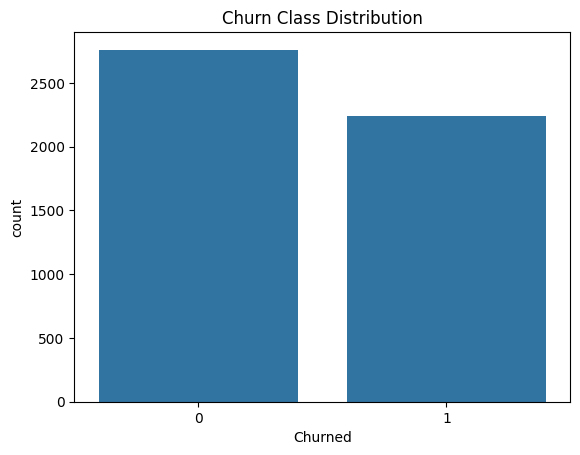

In [ ]:
sns.countplot(data=streaming_df, x='Churned')
plt.title('Churn Class Distribution')
plt.savefig("churn.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#class is imbalanced. Churned count is less than number who did not churn


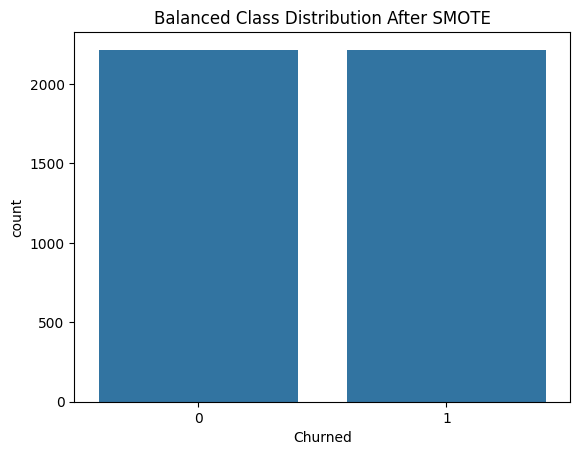

In [ ]:
# Plotting the new class distribution
sns.countplot(x=y_train_res)
plt.title("Balanced Class Distribution After SMOTE")
plt.savefig("churnbal.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Scaling the data
scaler = StandardScaler()
scaler.fit(x_train_res)
x_train_scaled = scaler.transform(x_train_res)
x_test_scaled = scaler.transform(x_test)

# Training the KNN classifier
churn_class = KNeighborsClassifier()
churn_class.fit(x_train_scaled, y_train_res)

KNeighborsClassifier()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       545
           1       1.00      1.00      1.00       455

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



<Figure size 640x480 with 0 Axes>

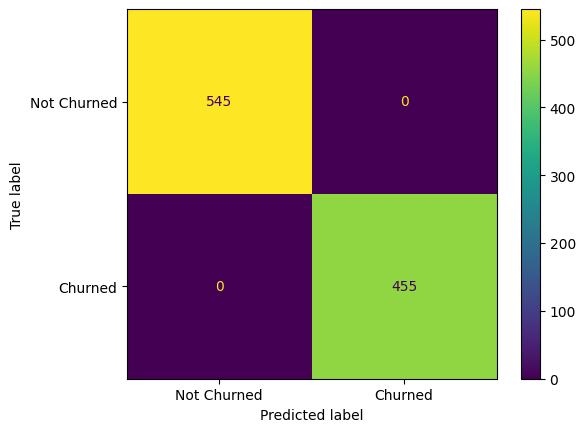

In [ ]:
# Making predictions on the clean (unseen) test set
churn_pred = churn_class.predict(x_test_scaled)

# Evaluation
conf_matrix = confusion_matrix(y_test, churn_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["Not Churned", "Churned"])
plt.savefig("confmap.png", dpi=300, bbox_inches='tight')
disp.plot()

# Print classification report
print(classification_report(y_test, churn_pred))

**(g)** Apply the k-Means clustering algorithm to identify different clusters in the streaming
service dataset. What is the optimal number of clusters (k) and why? Which features produce
the most meaningful clusters? Support your answer with visualizations and evaluation metrics.

**K-MEANS CLUSTERING**

**Clustering Monthly Monthly Spend by Satisfaction Score**

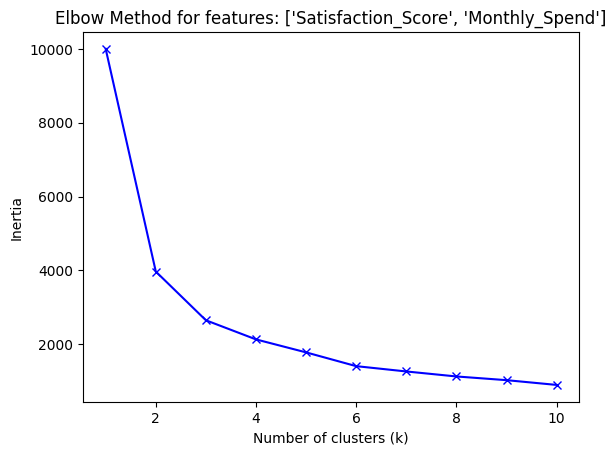

In [ ]:
from sklearn.cluster import KMeans

def plot_elbow(streaming_df, feature_names):
    # Extract features
    x = streaming_df[feature_names]

    # Scale features using StandardScaler
    scale = StandardScaler()
    scale.fit(x)
    x_scaled = scale.transform(x)

    # Prepare to collect inertia for k in 1 to 10
    inertia = []
    k_range = range(1, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(x_scaled)
        inertia.append(kmeans.inertia_)

    # Plot inertia vs k
    plt.plot(k_range, inertia, 'bx-')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method for features: {feature_names}")
    plt.savefig("elbow1.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_elbow(streaming_df, ["Satisfaction_Score", "Monthly_Spend"])

In [ ]:
from sklearn.metrics import davies_bouldin_score, silhouette_score

def fit_and_evaluate_kmeans(streaming_df, feature_names, k, title=None):
    # Extract features
    x = streaming_df[feature_names]

    # Scale features
    scale = StandardScaler()
    scale.fit(x)
    x_scaled = scale.transform(x)

    # Fit k-means model with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)

    # Predict cluster labels
    cluster_labels_pred = kmeans.predict(x_scaled)

    # Calculate evaluation metrics
    db_score = davies_bouldin_score(x_scaled, cluster_labels_pred)
    s_score = silhouette_score(x_scaled, cluster_labels_pred)

    # Print metrics
    print("Davies Bouldin Index: %.4f" % db_score)
    print("Silhouette Coefficient: %.4f" % s_score)

    # Visualize clusters
    sns.scatterplot(data=streaming_df, x=feature_names[0], y=feature_names[1], hue=cluster_labels_pred, palette='viridis')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title if title else f'K-Means Clustering (k={k})')
    plt.legend(title='Cluster')
    plt.savefig("clustsatfmonthly.png", dpi=300, bbox_inches='tight')
    plt.show()

Davies Bouldin Index: 0.8376
Silhouette Coefficient: 0.4074


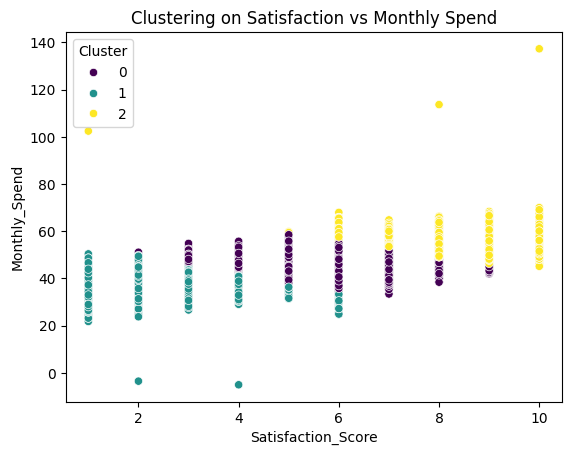

In [ ]:
fit_and_evaluate_kmeans(
    streaming_df, ["Satisfaction_Score", "Monthly_Spend"],
    3,
    title="Clustering on Satisfaction vs Monthly Spend"
)

**Clustering Monthly Spend by Discount_Offered**

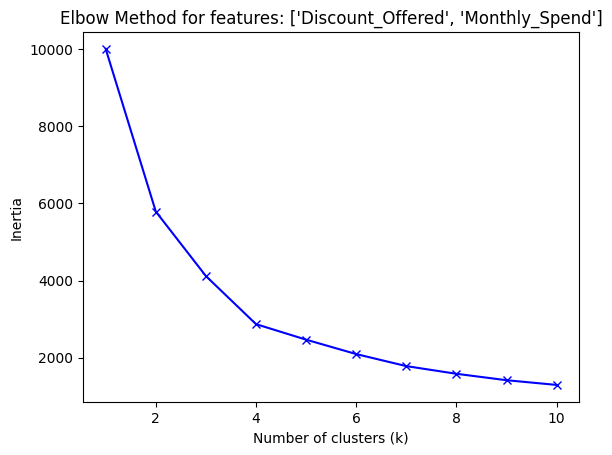

In [ ]:
plt.savefig("elbow2.png", dpi=300, bbox_inches='tight')
plot_elbow(streaming_df, ["Discount_Offered", "Monthly_Spend"])

Davies Bouldin Index: 0.8603
Silhouette Coefficient: 0.3731


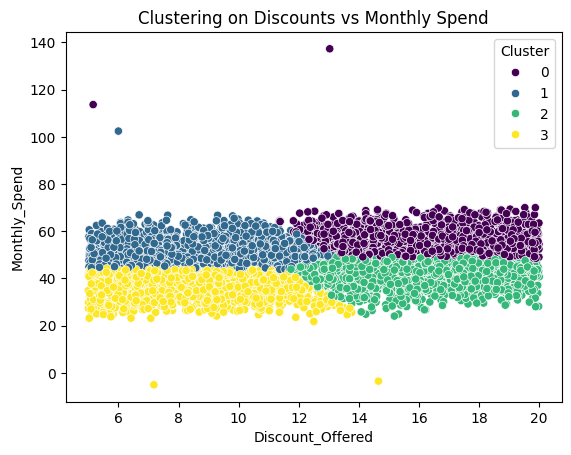

In [ ]:
#Elbow starts to flatten at 4. k = 4
#fitting, predicting and plotting clusters

fit_and_evaluate_kmeans(
    streaming_df, ["Discount_Offered", "Monthly_Spend"],
    4,
    title="Clustering on Discounts vs Monthly Spend"
)

the clusters show four different colours. 0 is in the upper right side and spans between around 45 and 60pounds, discount offered btween 12 and 20. 1 spans between 45 and 60 in the upper left for monthy spend around 4 and 14 for discount offered. 2 span between around 12 to 20 of discount offered and around 20 to 40 for monthly spend.  3 spans between 20 and around 40 for in in the lower left side with discount offered spanning between around 4 and 14.

In [ ]:
streaming_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     5000 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      5000 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


**Clustering for monthly spend and subscription length**

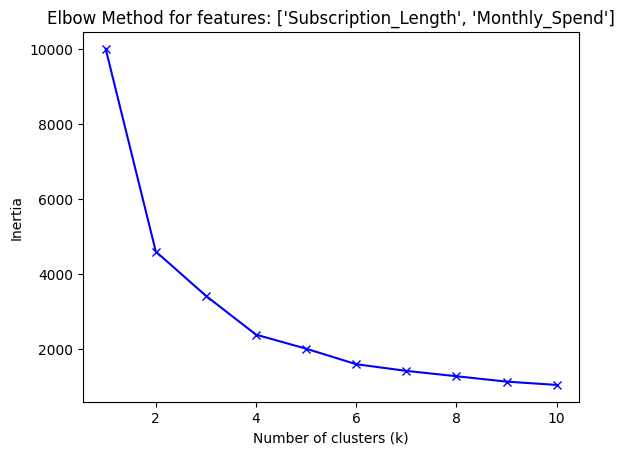

In [ ]:
plot_elbow(streaming_df, ["Subscription_Length", "Monthly_Spend"])

Davies Bouldin Index: 0.8352
Silhouette Coefficient: 0.3960


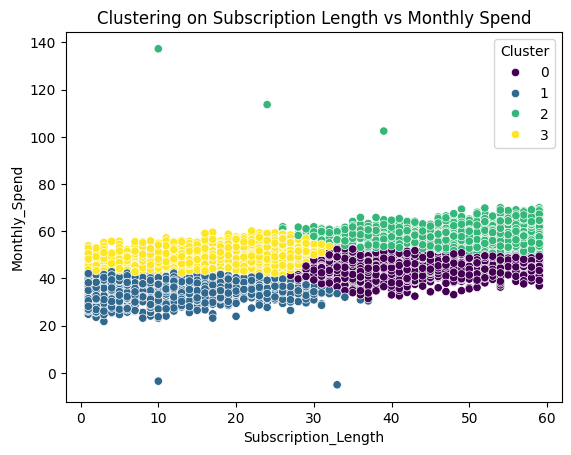

In [ ]:
#Elbow starts to flatten at 4. k = 4
#fitting, predicting and plotting clusters

fit_and_evaluate_kmeans(
    streaming_df, ["Subscription_Length", "Monthly_Spend"],
    4,
    title="Clustering on Subscription Length vs Monthly Spend"
)

**Triple feature clustering**

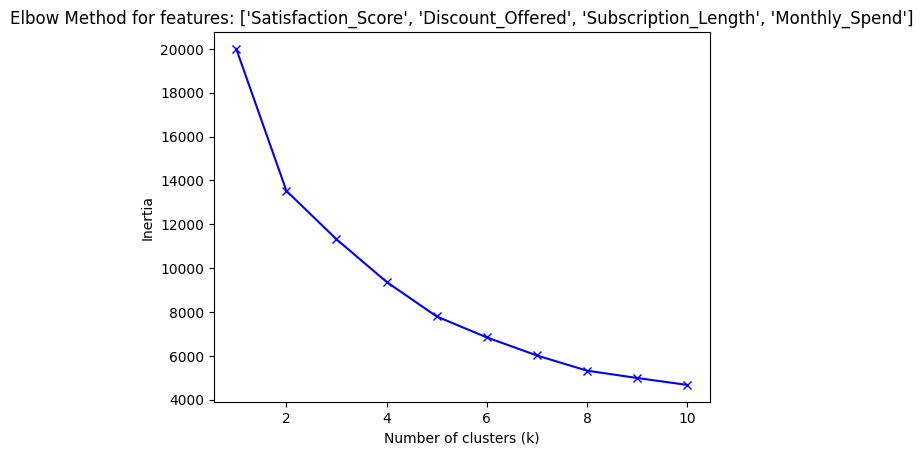

In [ ]:
plot_elbow(streaming_df, ["Satisfaction_Score", "Discount_Offered","Subscription_Length", "Monthly_Spend"])

In [ ]:
# Extract features as a DataFrame
x = streaming_df[["Satisfaction_Score", "Discount_Offered", "Subscription_Length", "Monthly_Spend"]]

# Scale features
scale = StandardScaler()
scale.fit(x)
x_scaled = scale.transform(x)

# Fit k-means model with n_clusters
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(x_scaled)

# Predict cluster labels
cluster_labels_pred = kmeans.predict(x_scaled)

# Calculate evaluation metrics
db_score = davies_bouldin_score(x_scaled, cluster_labels_pred)
s_score = silhouette_score(x_scaled, cluster_labels_pred)

# Print metrics
print("Davies Bouldin Index: %.4f" % db_score)
print("Silhouette Coefficient: %.4f" % s_score)

Davies Bouldin Index: 1.3743
Silhouette Coefficient: 0.2831


**(h)** Compare the k-Means clustering results from part (g) with another clustering algorithm
(e.g., Hierarchical Clustering or DBSCAN). Which algorithm provides the best segmentation
of customer behaviour, and why? Use evaluation metrics to justify your answer.

**Comparing Clustering Model with Heirachial and DB Scan**

**Identifying clusters for Satisfaction_Score, Monthly_Spend with Heirachial Clustering**

Davies Bouldin Score: 0.6340
Silhouette Score: 0.4795


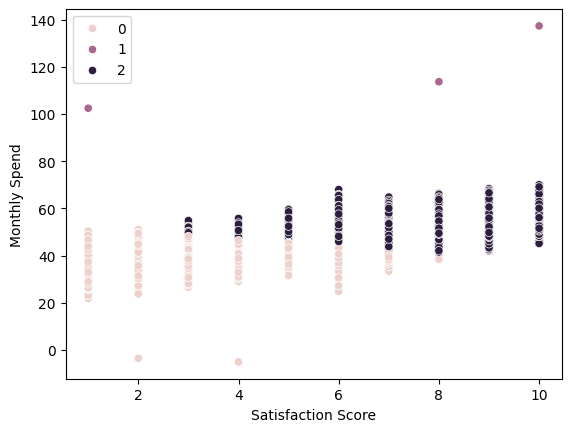

In [ ]:
# Extract the input features
feature_names = ["Satisfaction_Score", "Monthly_Spend"]
x = streaming_df[feature_names]

#Scale the input features
scale = StandardScaler()
scale.fit(x)
x_scaled = scale.transform(x)

# Import the AgglomerativeClustering model
from sklearn.cluster import AgglomerativeClustering

# Create an instance of the AgglomerativeClustering
# class, with 3 clusters and complete linkage.
agg_model = AgglomerativeClustering(n_clusters = 3, linkage = 'complete')

# Fitting the model
agg_labels_pred = agg_model.fit_predict(x_scaled)

#Applying the evaluation metrics.
# Calculate the Davies-Bouldin index
db_score = davies_bouldin_score(x_scaled, agg_labels_pred)

# Calculate the Silhouette coefficient
s_score = silhouette_score(x_scaled, agg_labels_pred)
 # Print the results
print("Davies Bouldin Score: %.4f" % (db_score, ))
print("Silhouette Score: %.4f" % (s_score, ))

# Visualise the clusters in a scatter plot of Life expectancy versus GDP
sns.scatterplot(data = streaming_df, x = "Satisfaction_Score", y = "Monthly_Spend", hue =agg_labels_pred)

# Label both axes
plt.xlabel("Satisfaction Score")
plt.ylabel("Monthly Spend")

# Show the figure
plt.show()

**DBScan**

Davies Bouldin Index: 3.1053
Silhouette Coefficient: 0.0697


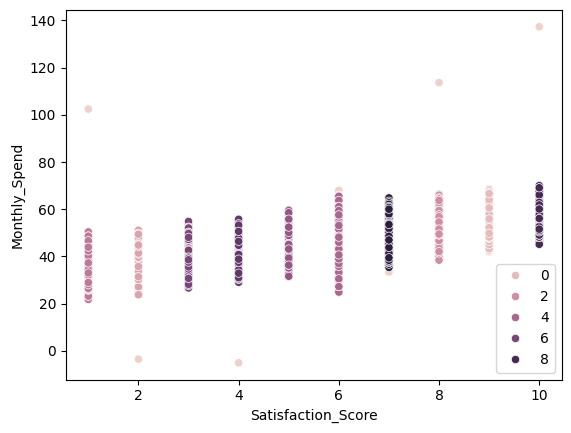

In [ ]:
# Extract the input features
feature_names = ["Satisfaction_Score", "Monthly_Spend"]
x = streaming_df[feature_names]

# Scale the input features
scale = StandardScaler()
scale.fit(x)

x_scaled = scale.transform(x)

# Import the DBSCAN model from sklearn.
from sklearn.cluster import DBSCAN

# Creating an instance of the DBSCAN class,
# setting the eps and min_samples parameters.
dbscan = DBSCAN(eps=0.2, min_samples=3)

# Fit the model to the input data and output
# the predicted cluster labels from this model.
dbscan_labels_pred = dbscan.fit_predict(x_scaled)

# Calculate the Davies-Bouldin index
db_score = davies_bouldin_score(x_scaled, dbscan_labels_pred)

# Calculate the Silhouette coefficient
s_score = silhouette_score(x_scaled, dbscan_labels_pred)

# Print the results
print("Davies Bouldin Index: %.4f" % (db_score, ))
print("Silhouette Coefficient: %.4f" % (s_score, ))

# Visualise the clusters
sns.scatterplot(data = streaming_df, x = "Satisfaction_Score", y = "Monthly_Spend", hue = dbscan_labels_pred)

# Label both axes
plt.xlabel("Satisfaction_Score")
plt.ylabel("Monthly_Spend")

# Show the plot
plt.show()